In [ ]:
# 📌 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

plt.style.use('ggplot')
np.random.seed(42)

In [ ]:
import os

base_path = '/content/data/5G_Traffic_Datasets'
dataframes = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(root, file)
            try:
                df_temp = pd.read_csv(file_path, nrows=20000)

                parts = root.split('/')
                df_temp['category'] = parts[-2]
                df_temp['app'] = parts[-1]

                dataframes.append(df_temp)
            except:
                pass

df = pd.concat(dataframes, ignore_index=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1488349, 20)


,No.,Time,Source,Destination,Protocol,Length,Info,category,app,Jun 21,2022 00:03:06.471027000 대한민국 표준시\t10.215.173.1\t52.94.232.230\t60,2022 14:50:10.073251000 대한민국 표준시\t10.215.173.1\t52.46.148.49\t60,Jun 22,2022 00:12:03.092183000 대한민국 표준시\t10.215.173.1\t52.46.148.49\t60,Jun 23,2022 18:25:53.315905000 대한민국 표준시\t10.215.173.1\t52.94.232.230\t60,2022 23:16:56.981846000 대한민국 표준시\t10.215.173.1\t52.94.228.85\t60,2022 21:30:06.015812000 대한민국 표준시\t10.215.173.1\t10.215.173.2\t64,2022 21:28:09.013732000 대한민국 표준시\t10.215.173.1\t52.94.243.7\t60,2022 10:48:50.389683000 대한민국 표준시\t10.215.173.1\t52.119.196.66\t60
0,1.0,2022-10-07 16:52:21.626130,10.215.173.1,10.215.173.2,DNS,75.0,Standard query 0x2501 A android.crashsight.wet...,Online_Game,Battleground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,2022-10-07 16:52:21.669026,10.215.173.2,10.215.173.1,DNS,430.0,Standard query response 0x2501 A android.crash...,Online_Game,Battleground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,2022-10-07 16:52:21.673356,10.215.173.1,150.109.29.250,TCP,60.0,48876 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,Online_Game,Battleground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,2022-10-07 16:52:21.772315,150.109.29.250,10.215.173.1,TCP,48.0,"443 > 48876 [SYN, ACK] Seq=0 Ack=1 Win=2048 ...",Online_Game,Battleground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,2022-10-07 16:52:21.772449,10.215.173.1,150.109.29.250,TCP,40.0,48876 > 443 [ACK] Seq=1 Ack=1 Win=79872 Len=0,Online_Game,Battleground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df[['Time', 'Length', 'category', 'app']]

df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values('Time')
df.set_index('Time', inplace=True)

df.head()

,Length,category,app
Time,,,
2022-05-29 07:03:14.974334,1278.0,Stored_Streaming,YouTube
2022-05-29 07:03:15.015039,1278.0,Stored_Streaming,YouTube
2022-05-29 07:03:15.015155,1278.0,Stored_Streaming,YouTube
2022-05-29 07:03:15.015294,1278.0,Stored_Streaming,YouTube
2022-05-29 07:03:15.015366,1278.0,Stored_Streaming,YouTube


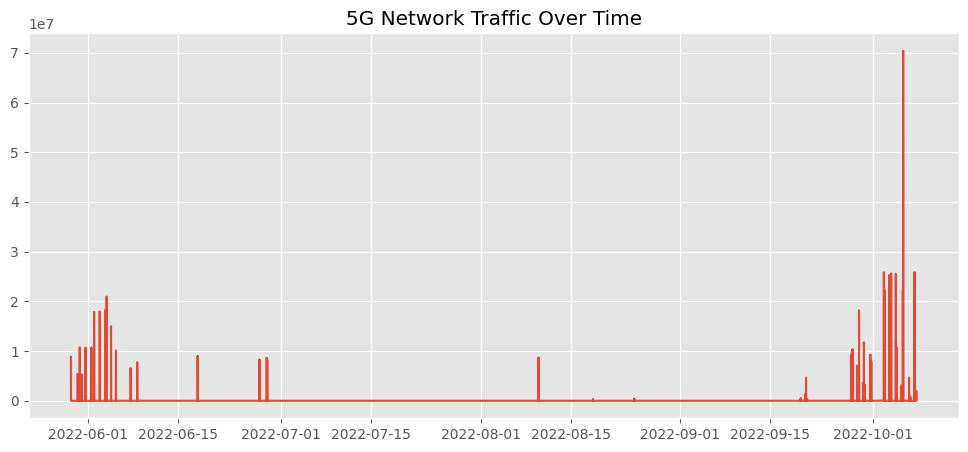

In [ ]:
traffic_df = df['Length'].resample('1min').sum()

plt.figure(figsize=(12,5))
plt.plot(traffic_df)
plt.title("5G Network Traffic Over Time")
plt.show()

In [ ]:
scaler = MinMaxScaler()

traffic_log = np.log1p(traffic_df)
scaled_data = scaler.fit_transform(traffic_log.values.reshape(-1,1))

In [ ]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(64))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train[:20000], y_train[:20000], epochs=5, batch_size=32)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - loss: 0.0012
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - loss: 9.4740e-04
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - loss: 8.7825e-04
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - loss: 8.5699e-04
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - loss: 8.4777e-04


In [ ]:
predictions = model.predict(X_test)

1183/1183 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step


In [ ]:
pred_real = scaler.inverse_transform(predictions)
pred_real = np.expm1(pred_real)

y_test_real = scaler.inverse_transform(y_test)
y_test_real = np.expm1(y_test_real)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0594
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0263
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0280
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0237
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0252
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Pred sample: [ 91968.53  103694.94  104566.055  99904.22   91798.875]
Actual sample: [329273.  17984.  21306.  16993.  16272.]


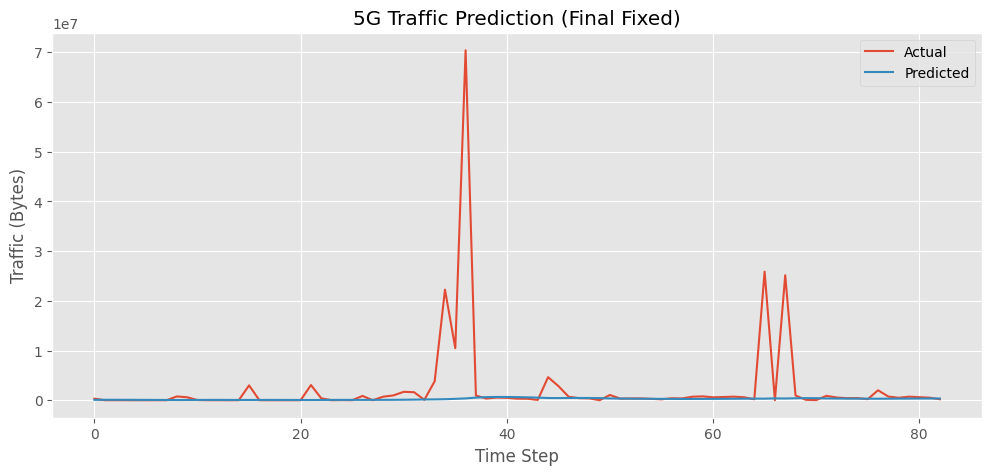

In [ ]:
# 🔥 COMPLETE FIXED TRAINING + PREDICTION (ONE CELL)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# STEP 1: REMOVE ZERO TRAFFIC
# -----------------------------
traffic_df = traffic_df[traffic_df > 0]

# -----------------------------
# STEP 2: LOG TRANSFORM + SCALE
# -----------------------------
scaler = MinMaxScaler()

traffic_log = np.log1p(traffic_df + 1)
scaled_data = scaler.fit_transform(traffic_log.values.reshape(-1,1))

# -----------------------------
# STEP 3: CREATE SEQUENCES
# -----------------------------
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# -----------------------------
# STEP 4: TRAIN-TEST SPLIT
# -----------------------------
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# STEP 5: BUILD MODEL
# -----------------------------
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(64))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# -----------------------------
# STEP 6: TRAIN MODEL (FAST)
# -----------------------------
model.fit(X_train[:20000], y_train[:20000], epochs=5, batch_size=32)

# -----------------------------
# STEP 7: PREDICT
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# STEP 8: INVERSE TRANSFORM
# -----------------------------
pred_real = scaler.inverse_transform(predictions)
pred_real = np.expm1(pred_real)

y_test_real = scaler.inverse_transform(y_test)
y_test_real = np.expm1(y_test_real)

# Flatten
pred_real = pred_real.flatten()
y_test_real = y_test_real.flatten()

# Clip to avoid overflow
pred_real = np.clip(pred_real, 0, 1e8)
y_test_real = np.clip(y_test_real, 0, 1e8)

# -----------------------------
# STEP 9: DEBUG CHECK
# -----------------------------
print("Pred sample:", pred_real[:5])
print("Actual sample:", y_test_real[:5])

# -----------------------------
# STEP 10: FINAL GRAPH
# -----------------------------
plt.figure(figsize=(12,5))

plt.plot(y_test_real[:500], label='Actual')
plt.plot(pred_real[:500], label='Predicted')

plt.legend()
plt.title("5G Traffic Prediction (Final Fixed)")
plt.xlabel("Time Step")
plt.ylabel("Traffic (Bytes)")
plt.show()

In [ ]:
pred_real = np.clip(pred_real, 0, 1e8)
y_test_real = np.clip(y_test_real, 0, 1e8)

mae = mean_absolute_error(y_test_real, pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2286532.9710090347
RMSE: 9070507.576789418


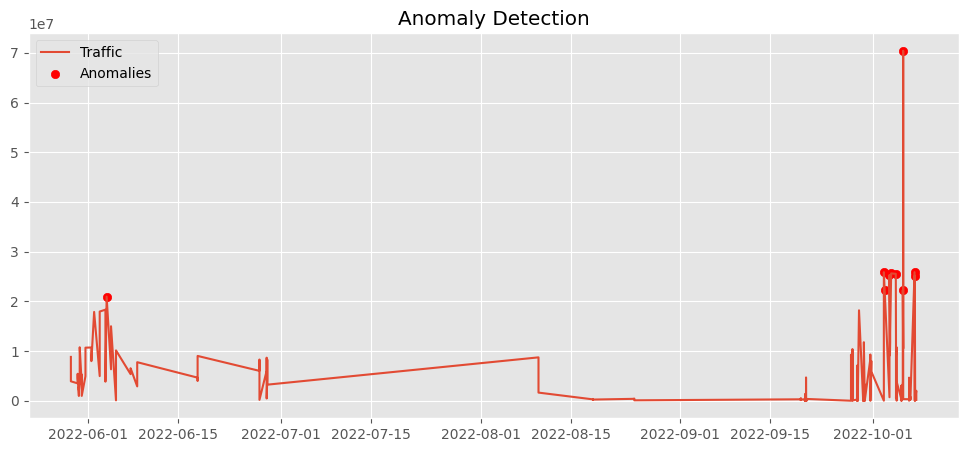

In [ ]:
threshold = traffic_df.mean() + 3 * traffic_df.std()
anomalies = traffic_df[traffic_df > threshold]

plt.figure(figsize=(12,5))
plt.plot(traffic_df, label='Traffic')
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomalies')
plt.legend()
plt.title("Anomaly Detection")
plt.show()

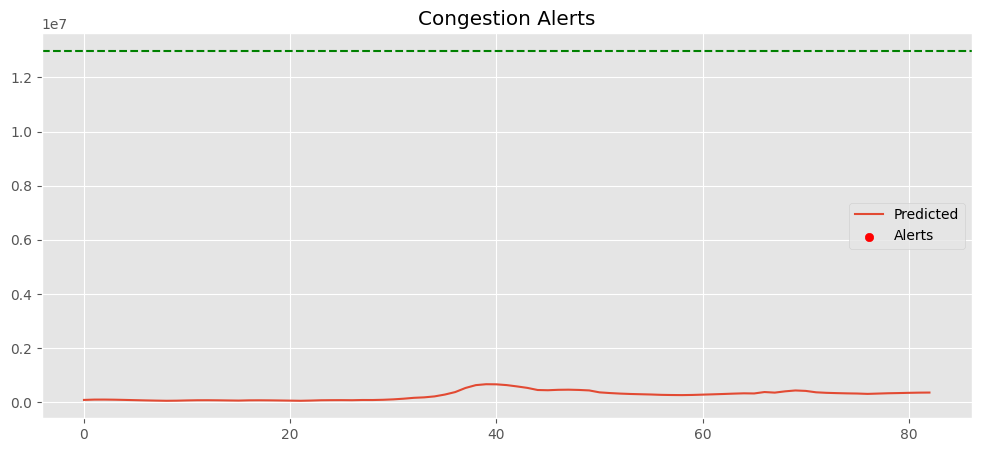

In [ ]:
alert_threshold = traffic_df.mean() + 2 * traffic_df.std()

alerts = pred_real.flatten() > alert_threshold
alert_idx = np.where(alerts)[0]

plt.figure(figsize=(12,5))
plt.plot(pred_real[:500], label='Predicted')

plt.scatter(alert_idx[:500],
            pred_real[alert_idx[:500]],
            color='red', label='Alerts')

plt.axhline(y=alert_threshold, color='green', linestyle='--')

plt.legend()
plt.title("Congestion Alerts")
plt.show()

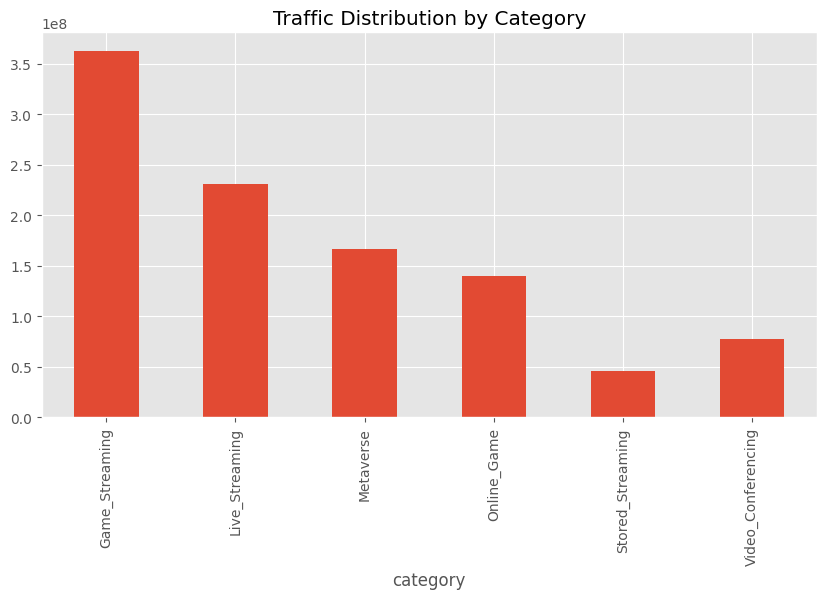

In [ ]:
df.groupby('category')['Length'].sum().plot(kind='bar', figsize=(10,5))
plt.title("Traffic Distribution by Category")
plt.show()

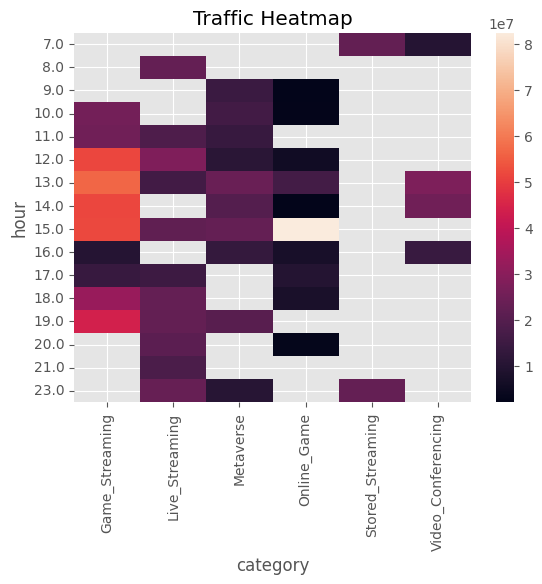

In [ ]:
df['hour'] = df.index.hour

heatmap = df.pivot_table(values='Length',
                         index='hour',
                         columns='category',
                         aggfunc='sum')

sns.heatmap(heatmap)
plt.title("Traffic Heatmap")
plt.show()